<a href="https://colab.research.google.com/github/asianman940121-crypto/-/blob/main/%E6%A9%9F%E5%99%A8%E5%AD%B8%E7%BF%92%E4%BD%9C%E6%A5%AD4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

成功讀取資料集！

=== 資料前處理完成 ===
原始收盤價總天數: 243
建構的數據對總數: 241
-------------------------
【訓練集】
X_train shape: (200, 2) (應為 200, 2)
Y_train shape: (200, 1) (應為 200, 1)
-------------------------
【測試集】
X_test shape: (41, 2)
Y_test shape: (41, 1)


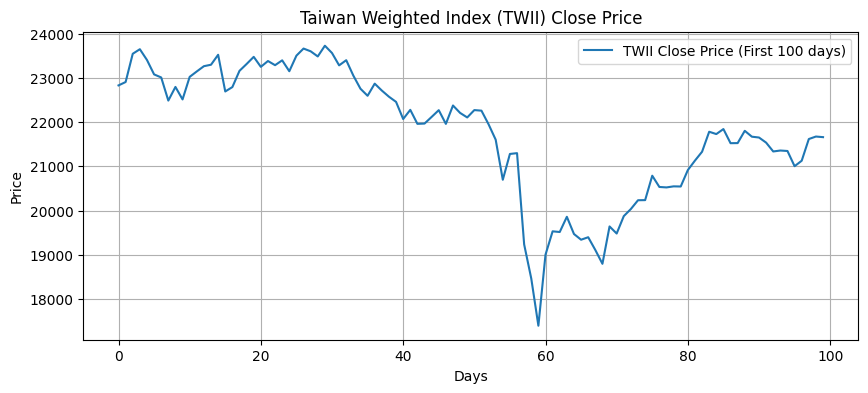

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. 載入資料集
# 請確保 DataSet__twii_history(2025).csv 已經上傳至 Colab 左側檔案區
file_path = 'DataSet__twii_history(2025).csv'
try:
    df = pd.read_csv(file_path)
    print("成功讀取資料集！")
except FileNotFoundError:
    print("找不到檔案，請確認是否已將 CSV 檔上傳至 Colab 喔！")

# 2. 提取「收盤價 (Close)」欄位資料
# 將其轉換為 numpy array 以利後續運算
close_prices = df['Close'].values

# 3. 建構滑動數據對 ([x_i, x_{i+1}] -> x_{i+2})
X_data = []
Y_data = []

# 迴圈跑到 len(close_prices) - 2，因為需要保留未來的一天作為 Y
for i in range(len(close_prices) - 2):
    # 輸入特徵：連續兩天的收盤價
    features = [close_prices[i], close_prices[i+1]]
    # 目標值：第三天的收盤價
    target = close_prices[i+2]

    X_data.append(features)
    Y_data.append(target)

# 轉成 Numpy 陣列，並將 Y 轉為 (N, 1) 的維度，方便後續神經網路運算
X_data = np.array(X_data)
Y_data = np.array(Y_data).reshape(-1, 1)

# 4. 切分訓練集與測試集 (依據作業要求：前 200 筆為訓練集)
num_train = 200

X_train = X_data[:num_train]
Y_train = Y_data[:num_train]

X_test = X_data[num_train:]
Y_test = Y_data[num_train:]

# 5. 防呆確認：印出資料維度
print("\n=== 資料前處理完成 ===")
print(f"原始收盤價總天數: {len(close_prices)}")
print(f"建構的數據對總數: {len(X_data)}")
print("-" * 25)
print(f"【訓練集】")
print(f"X_train shape: {X_train.shape} (應為 200, 2)")
print(f"Y_train shape: {Y_train.shape} (應為 200, 1)")
print("-" * 25)
print(f"【測試集】")
print(f"X_test shape: {X_test.shape}")
print(f"Y_test shape: {Y_test.shape}")

# (Optional) 畫出前 100 天的收盤價走勢，確認資料無誤
plt.figure(figsize=(10, 4))
plt.plot(close_prices[:100], label='TWII Close Price (First 100 days)')
plt.title('Taiwan Weighted Index (TWII) Close Price')
plt.xlabel('Days')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import numpy as np

class NeuroFuzzySystem:
    def __init__(self, num_inputs=2, num_rules=16):
        self.num_inputs = num_inputs
        self.num_rules = num_rules

        # 初始化參數空間
        self.c = np.zeros((num_rules, num_inputs))      # 高斯函數中心 (16, 2)
        self.sigma = np.ones((num_rules, num_inputs))   # 高斯函數標準差 (16, 2)
        self.a = np.zeros((num_rules, num_inputs + 1))  # 後鑑部線性參數 (16, 3)

    def decode_all_params(self, chrom):
        """
        演算法 A 使用：將 112 維的一維鯨魚粒子，解碼並填入 If-part 與 Then-part
        """
        # 1. 解碼 If-part (64個參數)
        if_params_end = self.num_rules * self.num_inputs * 2
        if_part = chrom[:if_params_end].reshape(2, self.num_rules, self.num_inputs)
        self.c = if_part[0]      # 前 32 個為 c
        self.sigma = if_part[1]  # 後 32 個為 sigma

        # 避免 sigma 為 0 導致除以零錯誤
        self.sigma = np.where(self.sigma == 0, 1e-8, self.sigma)

        # 2. 解碼 Then-part (48個參數)
        self.a = chrom[if_params_end:].reshape(self.num_rules, self.num_inputs + 1)

    def decode_if_params(self, chrom_if):
        """
        演算法 B 使用：僅解碼 64 維的 If-part 參數
        """
        if_part = chrom_if.reshape(2, self.num_rules, self.num_inputs)
        self.c = if_part[0]
        self.sigma = if_part[1]
        self.sigma = np.where(self.sigma == 0, 1e-8, self.sigma)

    def forward(self, X):
        """
        前向傳播：完全依照類神經網路「層 (Layer)」的觀念設計
        X 矩陣維度: (N, 2)，其中 N 為資料筆數
        """
        N = X.shape[0]

        # === Layer 1: 輸入層 (Input Layer) ===
        # 接收外部輸入特徵 [x1, x2]
        layer1_out = X # Shape: (N, 2)

        # === Layer 2: 隸屬度層 (Fuzzification Layer) ===
        # 計算高斯隸屬度。利用擴展維度進行矩陣運算，提升運算效率
        # X 擴展為 (N, 1, 2), c 與 sigma 擴展為 (1, 16, 2)
        X_expanded = layer1_out[:, np.newaxis, :]
        c_expanded = self.c[np.newaxis, :, :]
        sigma_expanded = self.sigma[np.newaxis, :, :]

        # 高斯公式: exp( -((x - c)^2) / (2 * sigma^2) )
        layer2_out = np.exp(-((X_expanded - c_expanded) ** 2) / (2 * (sigma_expanded ** 2)))
        # Shape: (N, 16, 2) -> 代表 N 筆資料在 16 條規則、2 個輸入下的各自隸屬度

        # === Layer 3: 激發強度層 (Firing Strength Layer) ===
        # T-norm 運算：將同條規則中所有輸入的隸屬度相乘
        layer3_out = np.prod(layer2_out, axis=2)
        # Shape: (N, 16) -> 每筆資料對應 16 條規則的火花強度 w^(k)

        # === Layer 4: 正規化層 (Normalization Layer) ===
        # 計算每條規則的權重佔總激發強度的比例
        w_sum = np.sum(layer3_out, axis=1, keepdims=True)
        w_sum = np.where(w_sum == 0, 1e-8, w_sum) # 防止除以 0
        layer4_out = layer3_out / w_sum
        # Shape: (N, 16) -> 正規化後的激發強度 \bar{w}^(k)

        # === Layer 5: 結論層 (Consequent Layer) ===
        # 計算一階 T-S 模糊規則的輸出值: y^(k) = a0 + a1*x1 + a2*x2
        # 先建立擴充輸入矩陣 [1, x1, x2]
        X_aug = np.hstack([np.ones((N, 1)), layer1_out]) # Shape: (N, 3)

        # 計算每條規則的輸出
        y_rules = np.dot(X_aug, self.a.T) # Shape: (N, 16)

        # 將正規化權重與規則輸出相乘
        layer5_out = layer4_out * y_rules # Shape: (N, 16)

        # === Layer 6: 輸出層 (Output Layer) ===
        # 進行解模糊化 (Defuzzification)，將所有規則的加權結果加總，得到最終預測股價
        layer6_out = np.sum(layer5_out, axis=1, keepdims=True) # Shape: (N, 1)

        return layer6_out, layer4_out

# === 測試 NFS 網路架構是否能正常發揮作用 ===
if __name__ == "__main__":
    # 建立模型實例
    nfs_test = NeuroFuzzySystem()

    # 隨機產生一個 112 維的粒子當作測試權重
    mock_particle = np.random.uniform(-1.0, 1.0, 112)

    # 解碼入模型
    nfs_test.decode_all_params(mock_particle)

    # 拿前面做好的 X_train (前200筆) 丟進去測試前向傳播
    # 注意：請確保您在前一個 Cell 運行的 X_train 還在記憶體中
    try:
        predictions, _ = nfs_test.forward(X_train)
        print("=== NFS 網路前向傳播測試成功 ===")
        print(f"輸入訓練集維度: {X_train.shape}")
        print(f"模型輸出預測維度: {predictions.shape} (應為 200, 1)")
    except NameError:
        print("提示：找不到 X_train，請確認第一階段的程式碼有成功執行喔！")

=== NFS 網路前向傳播測試成功 ===
輸入訓練集維度: (200, 2)
模型輸出預測維度: (200, 1) (應為 200, 1)


=== 開始執行演算法 A (WOA) ===
粒子數: 60, 總疊代次數: 3000 ... (請耐心等候)
Iteration 300/3000, Best MSE: 117151.22
Iteration 600/3000, Best MSE: 116555.53
Iteration 900/3000, Best MSE: 116555.53
Iteration 1200/3000, Best MSE: 116555.50
Iteration 1500/3000, Best MSE: 116555.50
Iteration 1800/3000, Best MSE: 116555.50
Iteration 2100/3000, Best MSE: 116555.48
Iteration 2400/3000, Best MSE: 116555.47
Iteration 2700/3000, Best MSE: 116555.47
Iteration 3000/3000, Best MSE: 116555.47

訓練完成！總耗時: 47.53 秒
演算法 A 最終 Train MSE: 116555.47


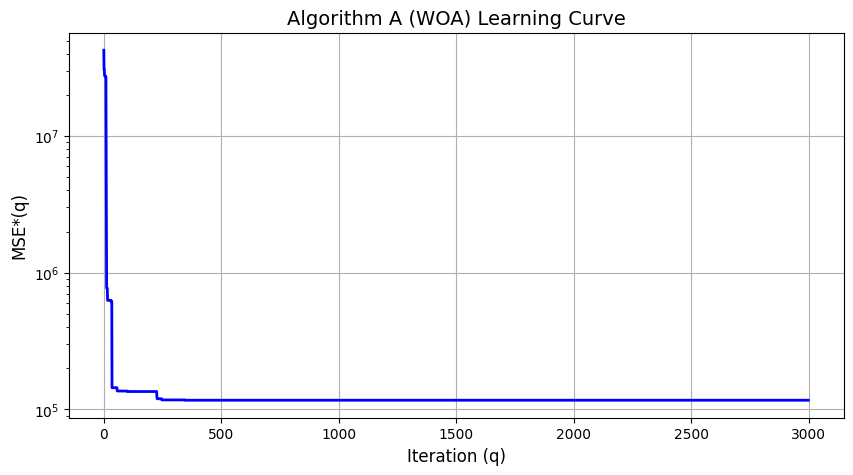

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time

# ==========================================
# 1. 定義演算法 A 的適應度函數 (Fitness Function)
# ==========================================
def fitness_function_A(particle, nfs_model, X, Y):
    # 將一維粒子解碼並填入 NFS 模型參數中
    nfs_model.decode_all_params(particle)
    # 進行前向傳播，取得預測值
    predictions, _ = nfs_model.forward(X)
    # 計算 MSE
    mse = np.mean((Y - predictions) ** 2)
    return mse

# ==========================================
# 2. 實作鯨群最佳化演算法 (WOA)
# ==========================================
def WOA_Algorithm_A(nfs_model, X, Y, num_whales=60, max_iter=3000):
    dim = 112 # 演算法A的總參數維度 (64 + 48)

    # --- 參數邊界設定 (Bounds) ---
    # c (中心): 32個參數，設定範圍 [20000, 30000] 以符合真實股價水準
    # sigma (標準差): 32個參數，設定範圍 [100, 5000]
    # a (Then-part 多項式係數): 48個參數，設定範圍 [-2, 2]
    lb = np.concatenate([np.ones(32)*20000, np.ones(32)*100, np.ones(48)*(-2)])
    ub = np.concatenate([np.ones(32)*30000, np.ones(32)*5000, np.ones(48)*2])

    # 初始化鯨魚族群位置 (在邊界內隨機生成)
    Positions = np.random.uniform(0, 1, (num_whales, dim)) * (ub - lb) + lb

    # 記錄全局最佳解與最佳 MSE
    Best_pos = np.zeros(dim)
    Best_score = float('inf')

    # 記錄每代的最佳 MSE，用於畫學習曲線
    Convergence_curve = np.zeros(max_iter)

    print(f"=== 開始執行演算法 A (WOA) ===")
    print(f"粒子數: {num_whales}, 總疊代次數: {max_iter} ... (請耐心等候)")
    start_time = time.time()

    for t in range(max_iter):
        # --- 步驟 A: 評估每隻鯨魚的適應度 ---
        for i in range(num_whales):
            # 邊界處理 (超出邊界則強行拉回)
            Positions[i, :] = np.clip(Positions[i, :], lb, ub)

            # 計算 MSE
            fitness = fitness_function_A(Positions[i, :], nfs_model, X, Y)

            # 更新全局最佳解
            if fitness < Best_score:
                Best_score = fitness
                Best_pos = Positions[i, :].copy()

        # --- 步驟 B: 更新 WOA 演算法控制參數 ---
        a = 2 - t * (2 / max_iter) # a 從 2 線性遞減至 0
        b = 1 # 螺旋常數

        # --- 步驟 C: 更新每隻鯨魚的位置 ---
        for i in range(num_whales):
            r1 = np.random.rand()
            r2 = np.random.rand()

            A = 2 * a * r1 - a
            C = 2 * r2

            p = np.random.rand() # 機率參數 (判斷要狩獵還是螺旋攻擊)
            l = (a - 1) * np.random.rand() + 1 # 用於螺旋更新的隨機數 l [-1, 1]

            if p < 0.5:
                if abs(A) >= 1:
                    # 1. 隨機搜尋獵物 (Search for prey) - 全域搜尋
                    rand_leader_index = np.random.randint(0, num_whales)
                    X_rand = Positions[rand_leader_index, :]
                    D_X_rand = abs(C * X_rand - Positions[i, :])
                    Positions[i, :] = X_rand - A * D_X_rand
                else:
                    # 2. 包圍獵物 (Encircling prey) - 區域收斂
                    D_Leader = abs(C * Best_pos - Positions[i, :])
                    Positions[i, :] = Best_pos - A * D_Leader
            else:
                # 3. 氣泡網攻擊 (Bubble-net attacking) - 螺旋更新
                distance2Leader = abs(Best_pos - Positions[i, :])
                Positions[i, :] = distance2Leader * np.exp(b * l) * np.cos(l * 2 * np.pi) + Best_pos

        # 記錄當代最佳 MSE
        Convergence_curve[t] = Best_score

        # 每 300 代印出一次進度，讓你知道它還在跑
        if (t + 1) % 300 == 0:
            print(f"Iteration {t+1}/{max_iter}, Best MSE: {Best_score:.2f}")

    end_time = time.time()
    print(f"\n訓練完成！總耗時: {end_time - start_time:.2f} 秒")
    print(f"演算法 A 最終 Train MSE: {Best_score:.2f}")

    return Best_pos, Convergence_curve

# ==========================================
# 3. 執行訓練並繪製學習曲線
# ==========================================
# 建立一個新的 NFS 模型專門給演算法 A 使用
nfs_model_A = NeuroFuzzySystem()

# 呼叫 WOA 進行訓練 (使用第一階段切好的 X_train, Y_train)
best_position_A, convergence_curve_A = WOA_Algorithm_A(nfs_model_A, X_train, Y_train, num_whales=60, max_iter=3000)

# 將訓練好的最佳參數正式寫入模型
nfs_model_A.decode_all_params(best_position_A)

# 依作業要求 (A)(1)：繪製學習曲線
plt.figure(figsize=(10, 5))
plt.plot(convergence_curve_A, color='blue', linewidth=2)
plt.title('Algorithm A (WOA) Learning Curve', fontsize=14)
plt.xlabel('Iteration (q)', fontsize=12)
plt.ylabel('MSE*(q)', fontsize=12)
plt.grid(True)
plt.yscale('log') # 使用對數座標較容易看出收斂趨勢
plt.show()

=== 開始執行演算法 B (WOA-RLSE) ===
粒子數: 30, 總疊代次數: 1000 ... (請耐心等候)
Iteration 100/1000, Best MSE: 57016.45
Iteration 200/1000, Best MSE: 55650.40
Iteration 300/1000, Best MSE: 55126.92
Iteration 400/1000, Best MSE: 55120.19
Iteration 500/1000, Best MSE: 55120.19
Iteration 600/1000, Best MSE: 55114.30
Iteration 700/1000, Best MSE: 54921.93
Iteration 800/1000, Best MSE: 54919.62
Iteration 900/1000, Best MSE: 54919.62
Iteration 1000/1000, Best MSE: 54915.75

訓練完成！總耗時: 103.38 秒
演算法 B 最終 Train MSE: 54915.75


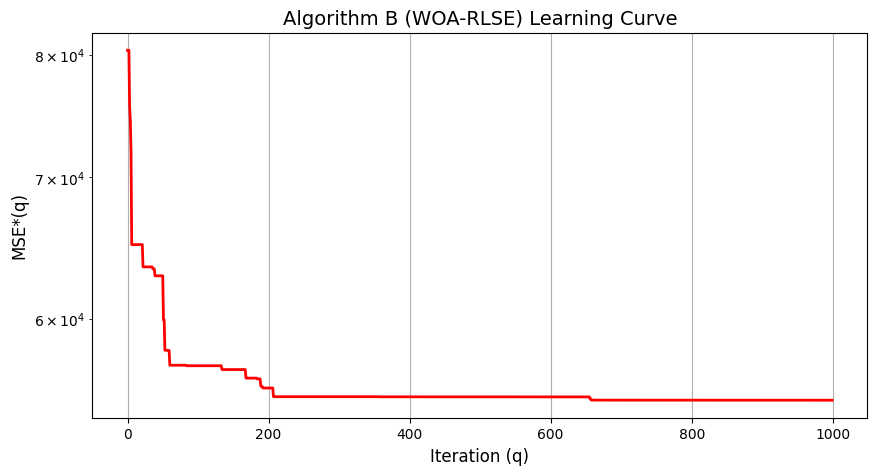

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time

# ==========================================
# 1. 實作 RLSE (遞歸最小平方法) 核心函數
# ==========================================
def run_RLSE(nfs_model, X, Y):
    N = X.shape[0]

    # 先做前向傳播到 Layer 4，取得正規化激發強度 (w_bar)
    # 這裡我們利用已經寫好的 forward，只取我們需要的 Layer 4 輸出
    _, layer4_out = nfs_model.forward(X) # layer4_out shape: (N, 16)

    # 建立擴充輸入矩陣 X_aug = [1, x1, x2] (N, 3)
    X_aug = np.hstack([np.ones((N, 1)), X])

    # 建立 RLSE 的設計矩陣 A_matrix (N, 48)
    # 每個資料點有 48 個 basis: w1, w1*x1, w1*x2, w2, w2*x1, w2*x2 ...
    A_matrix = np.zeros((N, 48))
    for k in range(16):
        A_matrix[:, k*3:(k+1)*3] = layer4_out[:, k:k+1] * X_aug

    # --- RLSE 參數初始化 (依作業要求) ---
    alpha = 1e9
    P = alpha * np.eye(48)        # P0 = αI
    theta = np.zeros((48, 1))     # θ0 = zero vector

    # --- 遞歸更新 (Recursive Update) ---
    for i in range(N):
        a_i = A_matrix[i, :].reshape(48, 1) # 第 i 筆資料的特徵向量 (48, 1)
        y_i = Y[i, 0]                       # 第 i 筆資料的真實值

        # 計算 Gain (K)
        # K = P * a_i / (1 + a_i^T * P * a_i)
        numerator = np.dot(P, a_i)
        denominator = 1.0 + np.dot(a_i.T, np.dot(P, a_i))[0, 0]
        K = numerator / denominator

        # 更新 θ (theta)
        # θ = θ + K * (y_i - a_i^T * θ)
        error = y_i - np.dot(a_i.T, theta)[0, 0]
        theta = theta + K * error

        # 更新 P
        # P = P - K * a_i^T * P
        P = P - np.dot(K, np.dot(a_i.T, P))

    # 將算出的 48 個參數重塑回 (16, 3) 並寫入模型
    nfs_model.a = theta.reshape(16, 3)

# ==========================================
# 2. 定義演算法 B 的適應度函數
# ==========================================
def fitness_function_B(particle_if, nfs_model, X, Y):
    # 1. 僅解碼 64 維的 If-part 參數
    nfs_model.decode_if_params(particle_if)

    # 2. 利用 RLSE 推導出最佳的 Then-part 參數並直接寫入模型
    run_RLSE(nfs_model, X, Y)

    # 3. 完整前向傳播，計算 MSE
    predictions, _ = nfs_model.forward(X)
    mse = np.mean((Y - predictions) ** 2)
    return mse

# ==========================================
# 3. 實作 WOA 演算法 (專門針對 If-part)
# ==========================================
def WOA_Algorithm_B(nfs_model, X, Y, num_whales=30, max_iter=1000):
    dim = 64 # 演算法B的 WOA 只訓練 If-part (32個c + 32個sigma)

    # --- 參數邊界設定 ---
    lb = np.concatenate([np.ones(32)*20000, np.ones(32)*100])
    ub = np.concatenate([np.ones(32)*30000, np.ones(32)*5000])

    # 初始化鯨魚族群位置
    Positions = np.random.uniform(0, 1, (num_whales, dim)) * (ub - lb) + lb

    Best_pos = np.zeros(dim)
    Best_score = float('inf')
    Convergence_curve = np.zeros(max_iter)

    print(f"=== 開始執行演算法 B (WOA-RLSE) ===")
    print(f"粒子數: {num_whales}, 總疊代次數: {max_iter} ... (請耐心等候)")
    start_time = time.time()

    for t in range(max_iter):
        for i in range(num_whales):
            # 邊界處理
            Positions[i, :] = np.clip(Positions[i, :], lb, ub)

            # 評估適應度 (內部會自動跑 RLSE)
            fitness = fitness_function_B(Positions[i, :], nfs_model, X, Y)

            if fitness < Best_score:
                Best_score = fitness
                Best_pos = Positions[i, :].copy()

        # WOA 參數更新
        a = 2 - t * (2 / max_iter)
        b = 1

        for i in range(num_whales):
            r1, r2 = np.random.rand(), np.random.rand()
            A = 2 * a * r1 - a
            C = 2 * r2
            p = np.random.rand()
            l = (a - 1) * np.random.rand() + 1

            if p < 0.5:
                if abs(A) >= 1:
                    rand_leader_index = np.random.randint(0, num_whales)
                    X_rand = Positions[rand_leader_index, :]
                    D_X_rand = abs(C * X_rand - Positions[i, :])
                    Positions[i, :] = X_rand - A * D_X_rand
                else:
                    D_Leader = abs(C * Best_pos - Positions[i, :])
                    Positions[i, :] = Best_pos - A * D_Leader
            else:
                distance2Leader = abs(Best_pos - Positions[i, :])
                Positions[i, :] = distance2Leader * np.exp(b * l) * np.cos(l * 2 * np.pi) + Best_pos

        Convergence_curve[t] = Best_score

        if (t + 1) % 100 == 0:
            print(f"Iteration {t+1}/{max_iter}, Best MSE: {Best_score:.2f}")

    end_time = time.time()
    print(f"\n訓練完成！總耗時: {end_time - start_time:.2f} 秒")
    print(f"演算法 B 最終 Train MSE: {Best_score:.2f}")

    return Best_pos, Convergence_curve

# ==========================================
# 4. 執行訓練並繪製學習曲線
# ==========================================
# 建立一個新的 NFS 模型給演算法 B 使用
nfs_model_B = NeuroFuzzySystem()

# 執行混合式演算法 (WOA-RLSE)
best_position_B, convergence_curve_B = WOA_Algorithm_B(nfs_model_B, X_train, Y_train, num_whales=30, max_iter=1000)

# 將最佳的 If-part 參數寫入，並跑最後一次 RLSE 確保 Then-part 是最完美的
nfs_model_B.decode_if_params(best_position_B)
run_RLSE(nfs_model_B, X_train, Y_train)

# 依作業要求 (A)(1)：繪製學習曲線
plt.figure(figsize=(10, 5))
plt.plot(convergence_curve_B, color='red', linewidth=2)
plt.title('Algorithm B (WOA-RLSE) Learning Curve', fontsize=14)
plt.xlabel('Iteration (q)', fontsize=12)
plt.ylabel('MSE*(q)', fontsize=12)
plt.grid(True)
plt.yscale('log')
plt.show()

             🏆 最終效能比較表 🏆
指標                   | 演算法 A (WOA)     | 演算法 B (WOA-RLSE)
--------------------------------------------------
Train MSE (前200筆)    | 116555.47       | 54915.75       
Test MSE (剩餘資料)      | 109110.94       | 103586.51      


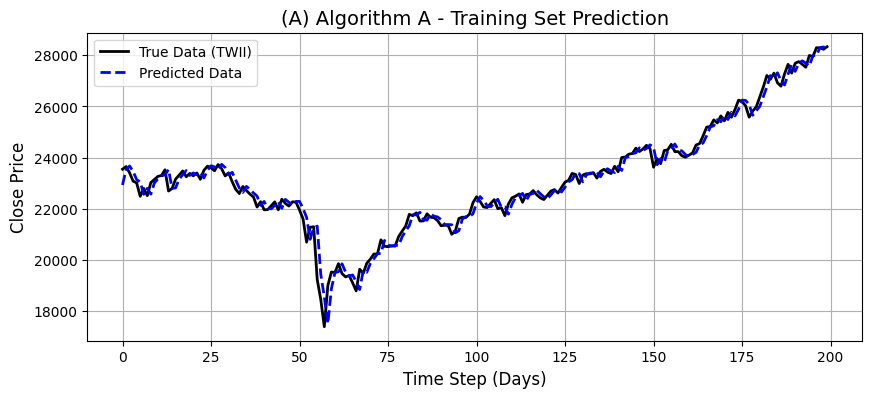

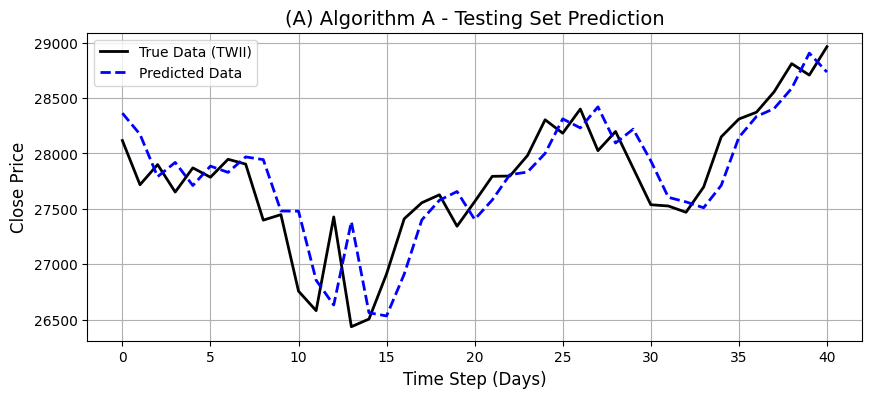

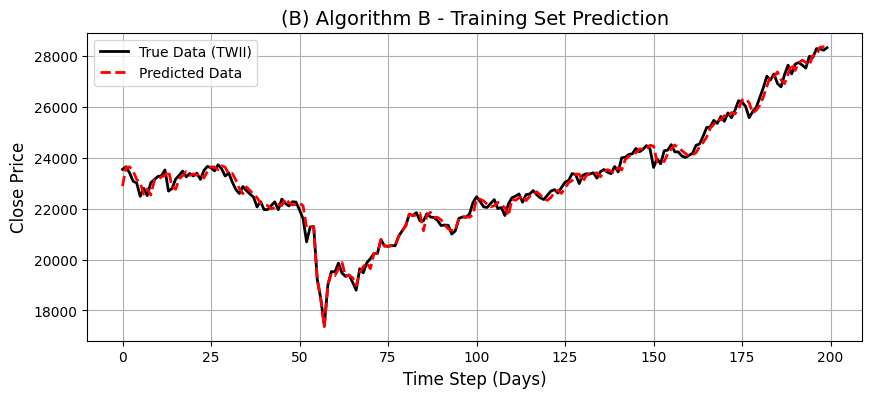

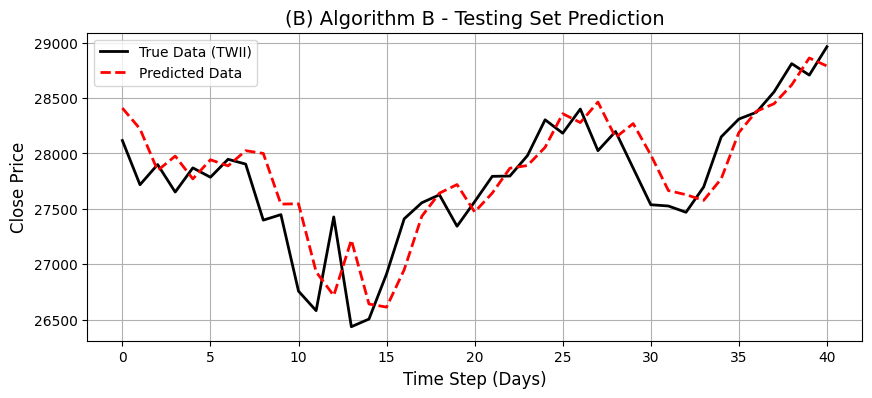

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. 使用訓練好的模型進行預測並計算測試集 MSE
# ==========================================
# --- 演算法 A (WOA) ---
train_pred_A, _ = nfs_model_A.forward(X_train)
test_pred_A, _ = nfs_model_A.forward(X_test)
test_mse_A = np.mean((Y_test - test_pred_A) ** 2)

# --- 演算法 B (WOA-RLSE) ---
train_pred_B, _ = nfs_model_B.forward(X_train)
test_pred_B, _ = nfs_model_B.forward(X_test)
test_mse_B = np.mean((Y_test - test_pred_B) ** 2)

# 列印最終的效能比較表 (供寫報告使用)
print("==================================================")
print("             🏆 最終效能比較表 🏆")
print("==================================================")
print(f"{'指標':<20} | {'演算法 A (WOA)':<15} | {'演算法 B (WOA-RLSE)':<15}")
print("-" * 50)
print(f"{'Train MSE (前200筆)':<20} | {np.mean((Y_train - train_pred_A)**2):<15.2f} | {np.mean((Y_train - train_pred_B)**2):<15.2f}")
print(f"{'Test MSE (剩餘資料)':<20} | {test_mse_A:<15.2f} | {test_mse_B:<15.2f}")
print("==================================================")

# ==========================================
# 2. 定義共用的繪圖函數
# ==========================================
def plot_prediction(true_data, pred_data, title, color):
    plt.figure(figsize=(10, 4))
    plt.plot(true_data, label='True Data (TWII)', color='black', linewidth=2)
    plt.plot(pred_data, label='Predicted Data', color=color, linestyle='--', linewidth=2)
    plt.title(title, fontsize=14)
    plt.xlabel('Time Step (Days)', fontsize=12)
    plt.ylabel('Close Price', fontsize=12)
    plt.legend()
    plt.grid(True)
    plt.show()

# ==========================================
# 3. 繪製作業要求的預測結果圖
# ==========================================
# --- 演算法 A ---
plot_prediction(Y_train, train_pred_A, '(A) Algorithm A - Training Set Prediction', 'blue')
plot_prediction(Y_test, test_pred_A, '(A) Algorithm A - Testing Set Prediction', 'blue')

# --- 演算法 B ---
plot_prediction(Y_train, train_pred_B, '(B) Algorithm B - Training Set Prediction', 'red')
plot_prediction(Y_test, test_pred_B, '(B) Algorithm B - Testing Set Prediction', 'red')